In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

sns.set()

In [2]:
df = pd.read_csv(r'C:\Users\Ranee\Downloads\archive\student_lifestyle_100k.csv')
df.head()

,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,1003,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,1004,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,1005,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Student_ID          100000 non-null  int64  
 1   Age                 100000 non-null  int64  
 2   Gender              100000 non-null  object 
 3   Department          100000 non-null  object 
 4   CGPA                100000 non-null  float64
 5   Sleep_Duration      100000 non-null  float64
 6   Study_Hours         100000 non-null  float64
 7   Social_Media_Hours  100000 non-null  float64
 8   Physical_Activity   100000 non-null  int64  
 9   Stress_Level        100000 non-null  int64  
 10  Depression          100000 non-null  bool   
dtypes: bool(1), float64(4), int64(4), object(2)
memory usage: 7.7+ MB


In [4]:
df.isnull().sum()

Student_ID            0
Age                   0
Gender                0
Department            0
CGPA                  0
Sleep_Duration        0
Study_Hours           0
Social_Media_Hours    0
Physical_Activity     0
Stress_Level          0
Depression            0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.describe()

,Student_ID,Age,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,51000.500000,21.009010,2.898316,6.996425,4.509517,3.503288,74.353180,4.131660
std,28867.657797,2.000382,0.532240,1.498682,1.976076,1.486852,43.366963,1.424151
min,1001.000000,18.000000,1.560000,3.000000,0.000000,0.000000,0.000000,2.000000
25%,26000.750000,19.000000,2.450000,6.000000,3.200000,2.500000,37.000000,3.000000
50%,51000.500000,21.000000,2.900000,7.000000,4.500000,3.500000,74.000000,4.000000
75%,76000.250000,23.000000,3.350000,8.000000,5.800000,4.500000,112.000000,5.000000
max,101000.000000,24.000000,4.000000,12.000000,12.800000,10.000000,149.000000,10.000000


In [14]:
df_missing = df.copy()

# create artificial missing values
df_missing.loc[0:10, "CGPA"] = np.nan

# check missing values before handling
print("Missing values before filling:")
print(df_missing.isnull().sum())

# fill missing values using mean imputation
df_missing["CGPA"] = df_missing["CGPA"].fillna(df_missing["CGPA"].mean())

# check missing values after handling
print("\nMissing values after filling:")
print(df_missing.isnull().sum())

Missing values before filling:
Student_ID             0
Age                    0
Gender                 0
Department             0
CGPA                  11
Sleep_Duration         0
Study_Hours            0
Social_Media_Hours     0
Physical_Activity      0
Stress_Level           0
Depression             0
dtype: int64

Missing values after filling:
Student_ID            0
Age                   0
Gender                0
Department            0
CGPA                  0
Sleep_Duration        0
Study_Hours           0
Social_Media_Hours    0
Physical_Activity     0
Stress_Level          0
Depression            0
dtype: int64


In [15]:
numerical_cols = df.select_dtypes(include=np.number).columns
print(numerical_cols)

Index(['Student_ID', 'Age', 'CGPA', 'Sleep_Duration', 'Study_Hours',
       'Social_Media_Hours', 'Physical_Activity', 'Stress_Level'],
      dtype='object')


In [16]:
Q1 = df[numerical_cols].quantile(0.25)
Q3 = df[numerical_cols].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower bounds:")
print(lower)

print("\nUpper bounds:")
print(upper)

Lower bounds:
Student_ID           -48998.5
Age                      13.0
CGPA                      1.1
Sleep_Duration            3.0
Study_Hours              -0.7
Social_Media_Hours       -0.5
Physical_Activity       -75.5
Stress_Level              0.0
dtype: float64

Upper bounds:
Student_ID            150999.5
Age                       29.0
CGPA                       4.7
Sleep_Duration            11.0
Study_Hours                9.7
Social_Media_Hours         7.5
Physical_Activity        224.5
Stress_Level               8.0
dtype: float64


In [17]:
outlier_counts = ((df[numerical_cols] < lower) | (df[numerical_cols] > upper)).sum()
print("Outlier count in each numerical column:")
print(outlier_counts)

Outlier count in each numerical column:
Student_ID              0
Age                     0
CGPA                    0
Sleep_Duration        369
Study_Hours           432
Social_Media_Hours    328
Physical_Activity       0
Stress_Level          478
dtype: int64


In [18]:
df_no_outliers = df[~((df[numerical_cols] < lower) | (df[numerical_cols] > upper)).any(axis=1)]

print("Original shape:", df.shape)
print("Shape after removing outliers:", df_no_outliers.shape)

Original shape: (100000, 11)
Shape after removing outliers: (98409, 11)


In [19]:
df_minmax = df.copy()

minmax_scaler = MinMaxScaler()
df_minmax[numerical_cols] = minmax_scaler.fit_transform(df_minmax[numerical_cols])

df_minmax.head()

,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,0.00000,0.666667,Female,Science,0.795082,0.477778,0.257812,0.34,0.765101,0.375,False
1,0.00001,0.333333,Male,Engineering,0.475410,0.277778,0.562500,0.60,0.953020,0.000,False
2,0.00002,0.333333,Male,Medical,0.594262,0.266667,0.179688,0.18,0.919463,0.125,False
3,0.00003,0.500000,Male,Engineering,0.848361,0.566667,0.156250,0.46,0.872483,0.125,False
4,0.00004,0.166667,Male,Arts,0.647541,0.422222,0.203125,0.43,0.026846,0.500,False


In [20]:
df_zscore = df.copy()

zscore_scaler = StandardScaler()
df_zscore[numerical_cols] = zscore_scaler.fit_transform(df_zscore[numerical_cols])

df_zscore.head()

,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,-1.732033,0.495403,Female,Science,1.130481,0.202562,-0.612083,-0.069468,0.914222,0.609728,False
1,-1.731999,-0.504411,Male,Engineering,-0.335030,-0.998499,1.361535,1.679202,1.559878,-1.496801,False
2,-1.731964,-0.504411,Male,Medical,0.209839,-1.065225,-1.118139,-1.145572,1.444582,-0.794625,False
3,-1.731930,-0.004504,Male,Engineering,1.374733,0.736367,-1.269956,0.737610,1.283168,-0.794625,False
4,-1.731895,-1.004318,Male,Arts,0.454091,-0.131066,-0.966322,0.535841,-1.622284,1.311904,False


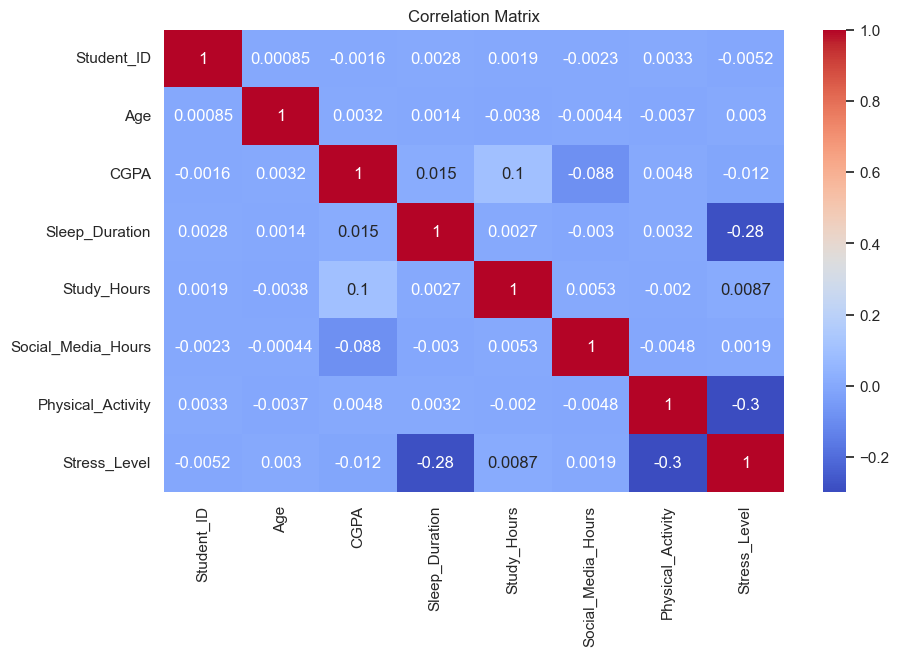

In [21]:
corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [22]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[numerical_cols])

pca = PCA(n_components=2)
principal_components = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(principal_components, columns=["PC1", "PC2"])
pca_df.head()

,PC1,PC2
0,-0.164676,0.485670
1,-1.282821,-0.459842
2,-0.796039,-0.060224
3,-1.601889,-0.124517
4,1.827742,-0.313190


In [23]:
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

Explained variance ratio: [0.17644756 0.14126286]
Total explained variance: 0.3177104233866994


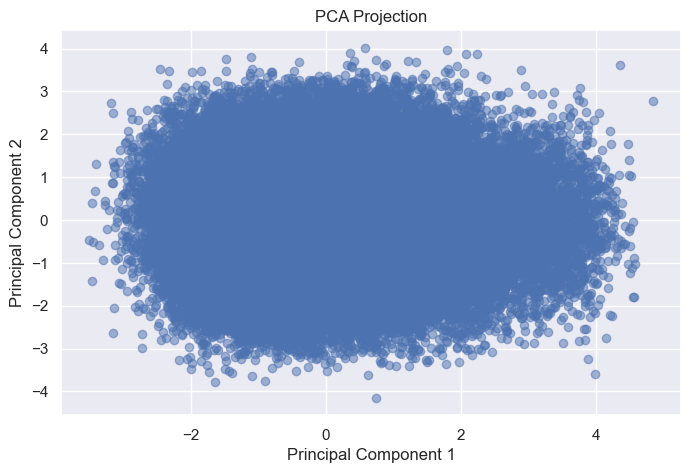

In [24]:
plt.figure(figsize=(8, 5))
plt.scatter(pca_df["PC1"], pca_df["PC2"], alpha=0.5)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection")
plt.show()